# Bank Loan Approval Prediction Using Machine Learning
### A Comparative Analysis of Logistic Regression, Decision Tree & Random Forest

---

**Problem Statement :** Banks need an efficient way to assess loan applications and predict which customers are likely to be approved, reducing risk and improving decision-making speed.

**Dataset :** The dataset contains 5,000 customer records with features such as Age, Experience, Income, Family Size, CCAvg, Education, Mortgage, Securities Account, CD Account, Online, Credit Card, and Personal Loan. The target variable is `Personal.Loan`, where 0 indicates the loan was not approved and 1 indicates the loan was approved.

**Objective :** To perform Exploratory Data Analysis (EDA) on the bank loan dataset and build three classification models — Logistic Regression, Decision Tree, and Random Forest — to predict loan approval. The models are evaluated using Accuracy and AUC-ROC scores to identify the best-performing algorithm and to find out which is the best model.

In [1]:
# Step 1 - Import Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from warnings import filterwarnings
filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

In [3]:
pwd()

'C:\\Users\\adi89\\Github-Projects\\Mini Project 5 - Bank Loan Approval - Implement of Logistic Regression, Decision Tree, Random Forest and AUC'

In [3]:
# Step 2 - Import dataset
# Dataset Link - https://www.kaggle.com/datasets/vikramamin/bank-loan-approval-lr-dt-rf-and-auc

data = pd.read_csv("Dataset/bankloan.csv")
data

,ID,Age,Experience,Income,ZIP.Code,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


#### Step 3 - Explore data (EDA)


In [5]:
data.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP.Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal.Loan', 'Securities.Account',
       'CD.Account', 'Online', 'CreditCard'],
      dtype='str')

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP.Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal.Loan       5000 non-null   int64  
 10  Securities.Account  5000 non-null   int64  
 11  CD.Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIP.Code,5000.0,93152.503000,2121.852197,9307.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal.Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


In [9]:
data.isna().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP.Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal.Loan         0
Securities.Account    0
CD.Account            0
Online                0
CreditCard            0
dtype: int64

In [12]:
data.duplicated().sum()

0

In [10]:
data.nunique()

ID                    5000
Age                     45
Experience              47
Income                 162
ZIP.Code               467
Family                   4
CCAvg                  108
Education                3
Mortgage               347
Personal.Loan            2
Securities.Account       2
CD.Account               2
Online                   2
CreditCard               2
dtype: int64

In [13]:
data['Family'].unique()

array([4, 3, 1, 2], dtype=int64)

In [14]:
data['Education'].unique()

array([1, 2, 3], dtype=int64)

In [15]:
data['Personal.Loan'].unique()

array([0, 1], dtype=int64)

In [16]:
data['CreditCard'].unique()

array([0, 1], dtype=int64)

In [28]:
# Checking count of categorial columns

for col in['Family', 'Education', 'Personal.Loan', 'Securities.Account', 'CD.Account', 'Online', 'CreditCard']:
    print(f"\n Counts for {col}")
    
    print(data[col].value_counts())


 Counts for Family
Family
1    1472
2    1296
4    1222
3    1010
Name: count, dtype: int64

 Counts for Education
Education
1    2096
3    1501
2    1403
Name: count, dtype: int64

 Counts for Personal.Loan
Personal.Loan
0    4520
1     480
Name: count, dtype: int64

 Counts for Securities.Account
Securities.Account
0    4478
1     522
Name: count, dtype: int64

 Counts for CD.Account
CD.Account
0    4698
1     302
Name: count, dtype: int64

 Counts for Online
Online
1    2984
0    2016
Name: count, dtype: int64

 Counts for CreditCard
CreditCard
0    3530
1    1470
Name: count, dtype: int64


### Step 4 - Visualization

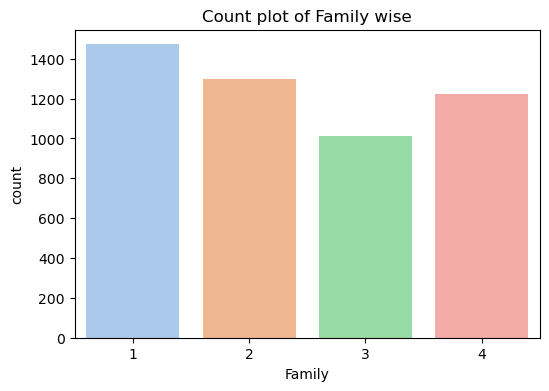

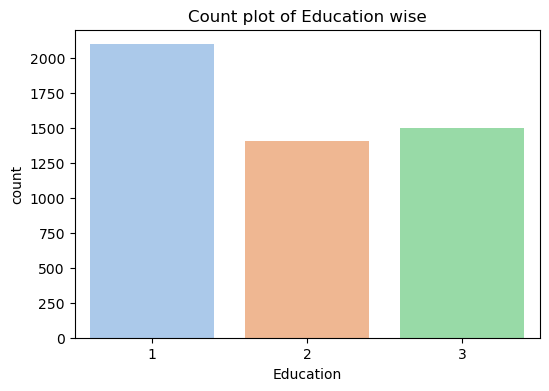

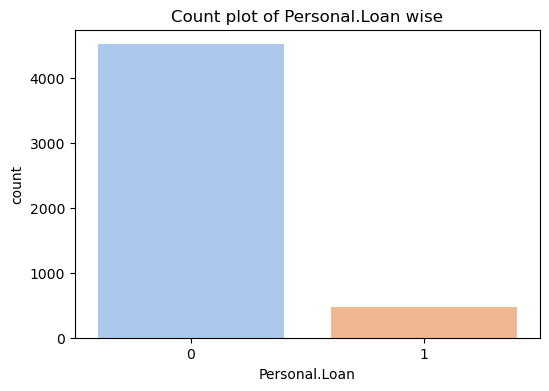

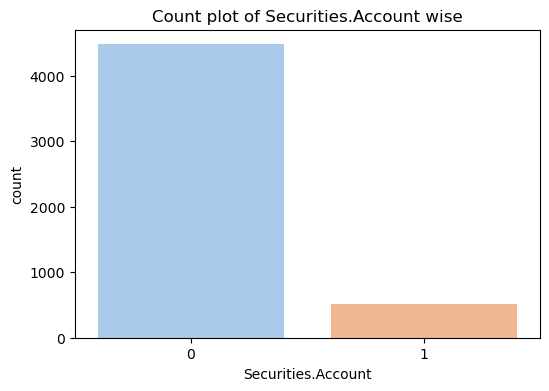

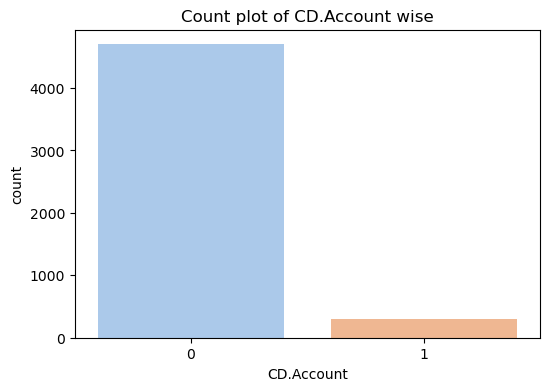

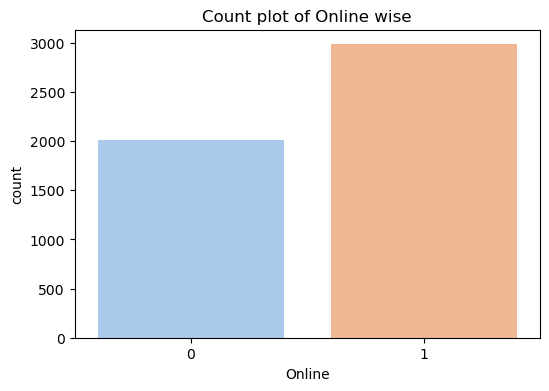

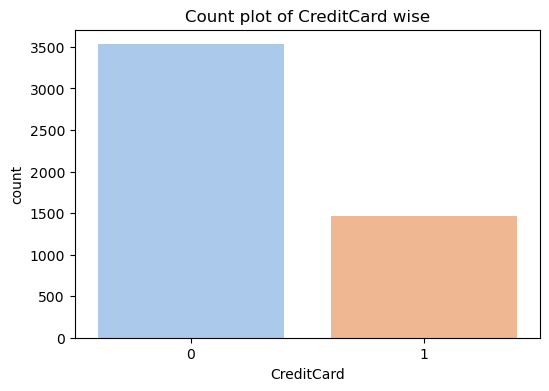

In [4]:
for col in['Family', 'Education', 'Personal.Loan', 'Securities.Account', 'CD.Account', 'Online', 'CreditCard']:
    plt.figure(figsize=(6, 4))   # optional, to control size
    sns.countplot(x = col, data = data, palette = 'pastel')
    plt.title(f'Count plot of {col} wise')
    # unique filename per column
    plt.savefig(f'Countplot_{col}.png', dpi=300, bbox_inches='tight')
    plt.show()

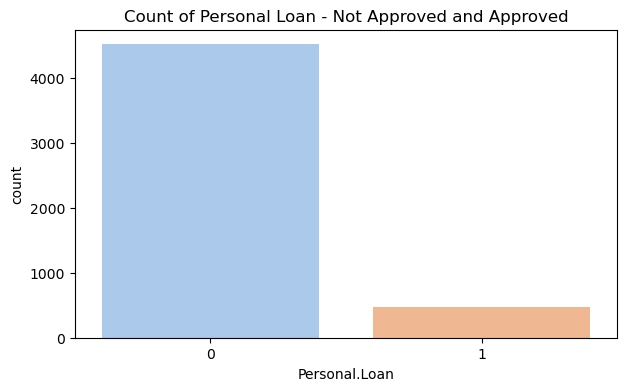

In [10]:
# I am showing separately countplot for "Personal.Loan" because it is our dependent variable

plt.figure(figsize =(7, 4))
sns.countplot( x = 'Personal.Loan', data = data, palette = 'pastel')
plt.title('Count of Personal Loan - Not Approved and Approved')
plt.savefig('Count plot of Personal Loan - Not Approved and Approved.png', dpi=300, bbox_inches='tight')
plt.show()

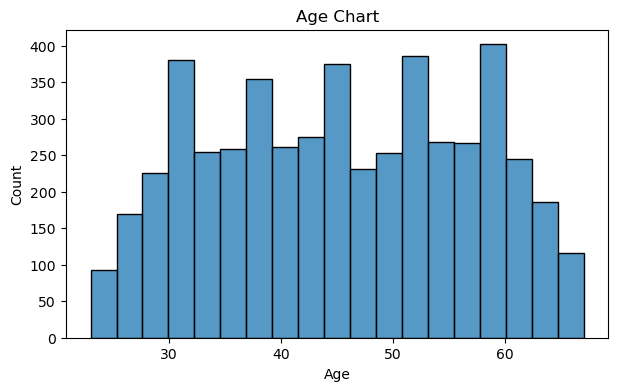

In [5]:
plt.figure(figsize =(7, 4))
sns.histplot(x = 'Age', data = data )
plt.title('Age Chart')
plt.savefig('Age chart of dataset.png', dpi=300, bbox_inches='tight')
plt.show()

In [45]:
data.groupby('Personal.Loan')['Age'].count()

Personal.Loan
0    4520
1     480
Name: Age, dtype: int64

In [5]:
# from dataset owner i get to know below analysis and visualization 
# when i recheck dataset and i think that data analysis and visualization is also good for our notebook presentation 
# so i also includes them in our notebook and it is as follow until preprocessing step:-

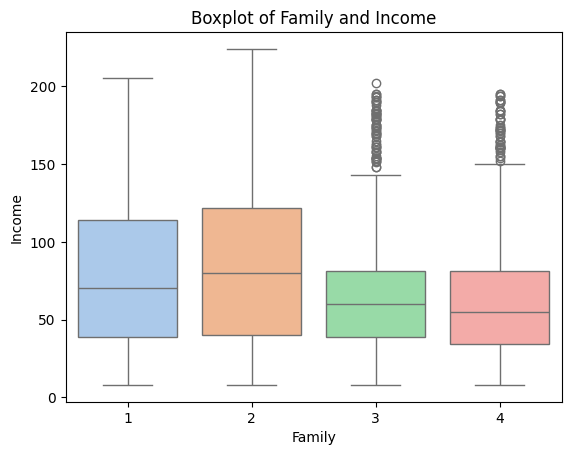

In [8]:
sns.boxplot( x = 'Family', y = 'Income', data = data, palette = 'pastel')
plt.title('Boxplot of Family and Income')
plt.show()

##### FROM ABOVE BOXPLOT, THIS INDICATES THAT INCOME IS HIGHER WHEN THERE ARE LESS FAMILY MEMBERS

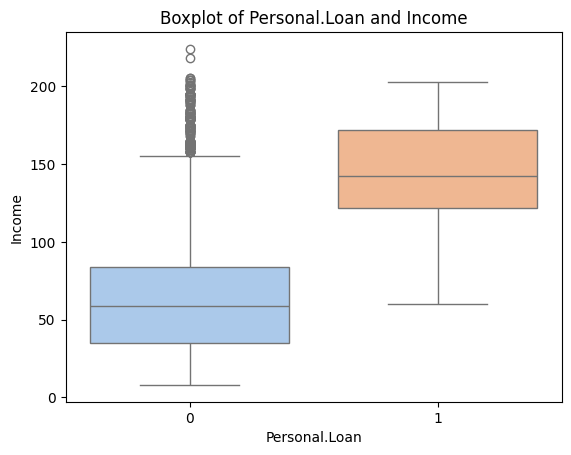

In [9]:
sns.boxplot( x = 'Personal.Loan', y = 'Income', data = data, palette = 'pastel')
plt.title('Boxplot of Personal.Loan and Income')
plt.show()

##### THIS INDICATES PERSONAL LOAN HAS BEEN APPROVED FOR CUSTOMERS HAVING HIGHER INCOME

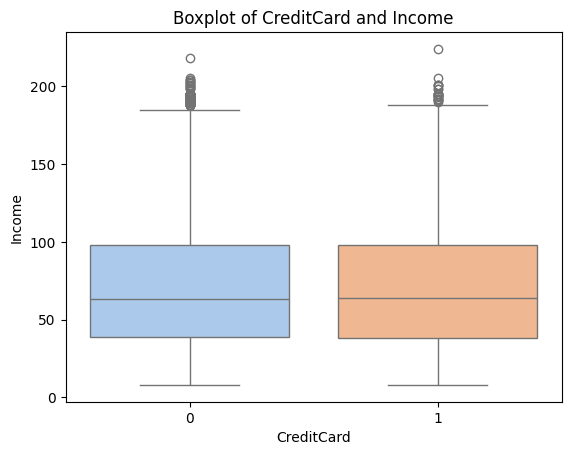

In [12]:
sns.boxplot( x = 'CreditCard', y = 'Income', data = data, palette = 'pastel')
plt.title('Boxplot of CreditCard and Income')
plt.show()

##### THIS INDICATES THAT THE INCOME IS PRETTY SIMILAR FOR CUSTOMERS OWNING AND NOT OWNING A CREDIT CARD

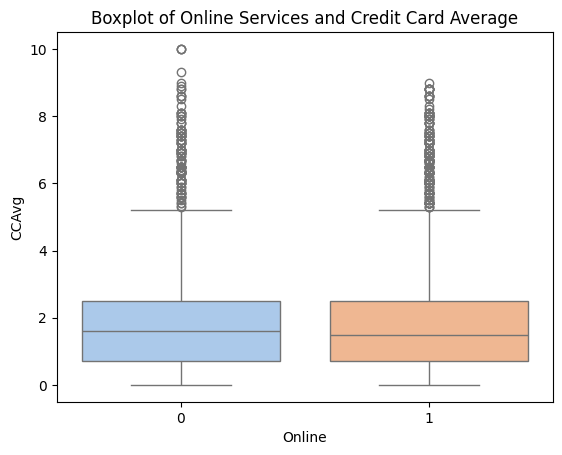

In [16]:
sns.boxplot( x = 'Online', y = 'CCAvg', data = data, palette = 'pastel')
plt.title('Boxplot of Online Services and Credit Card Average')
plt.show()

##### CC AVG IS PRETTY SIMILAR FOR THOSE WHO OPTED FOR ONLINE SERVICES AND THOSE WHO DID NOT

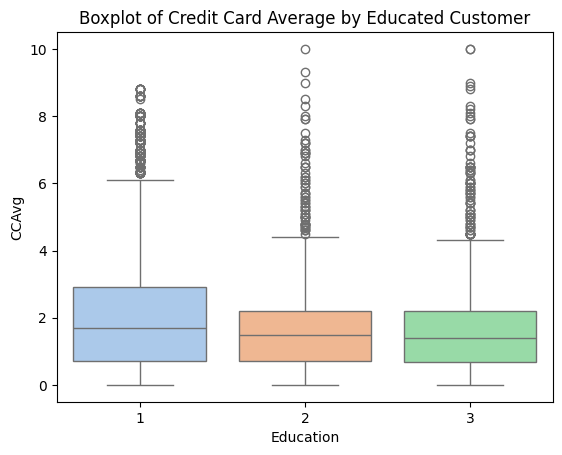

In [20]:
sns.boxplot( x = 'Education', y = 'CCAvg', data = data, palette = 'pastel')
plt.title('Boxplot of Credit Card Average by Educated Customer')
plt.show()

##### MORE EDUCATED CUSTOMERS HAVE A HIGHER CREDIT AVERAGE

In [19]:
# To understand of the impact of variables like Age and Income, 
# it is better to put them in range or category

data1 = data.copy()
data1['Age_range'] = pd.cut(data['Age'], 
                            bins = [22, 30, 40, 50, 60, 70],
                            labels = ['22-30','31-40', '41-50', '51-60', '61-70'])

data1['Income_Class'] = pd.cut(data['Income'], 
                               bins = [7, 24, 100, 150, 200, 230],
                               labels = ['Poor','MiddleClass', 'UpperMiddleClass', 'Rich', 'SuperRich'])
data1.head(5)

,ID,Age,Experience,Income,ZIP.Code,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard,Age_range,Income_Class
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0,22-30,MiddleClass
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0,41-50,MiddleClass
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0,31-40,Poor
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0,31-40,MiddleClass
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1,31-40,MiddleClass


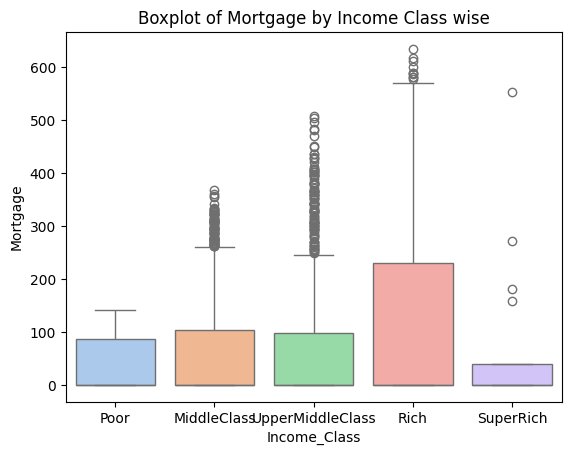

In [23]:
sns.boxplot( x = 'Income_Class', y = 'Mortgage', data = data1, palette = 'pastel')
plt.title('Boxplot of Mortgage by Income Class wise')
plt.show()

##### CUSTOMERS BELONGING TO THE RICH CLASS (INCOME GROUP : 150-200) HAVE THE HIGHEST MORTGAGE

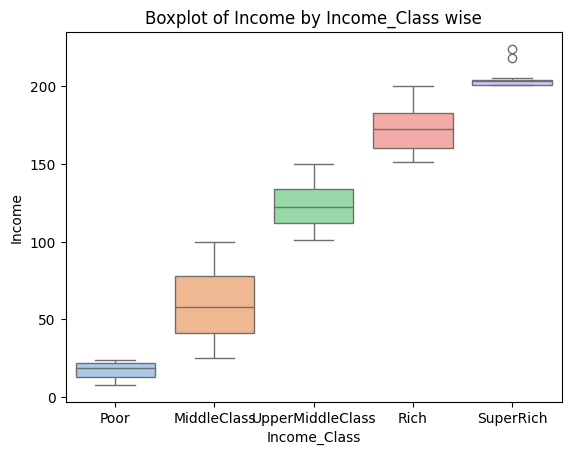

In [29]:
sns.boxplot( x = 'Income_Class', y = 'Income', data = data1, palette = 'pastel')
plt.title('Boxplot of Income by Income_Class wise')
plt.show()

##### CUSTOMERS BELONGING TO THE SUPER RICH CLASS (INCOME GROUP : 200-230) HAVE THE HIGHEST INCOME

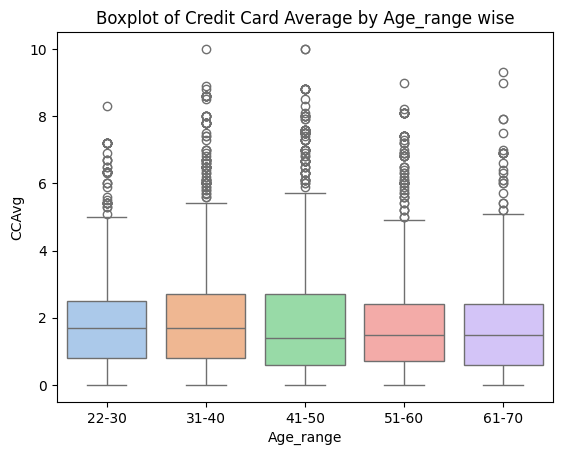

In [24]:
sns.boxplot( x = 'Age_range', y = 'CCAvg', data = data1, palette = 'pastel')
plt.title('Boxplot of Credit Card Average by Age_range wise')
plt.show()

###### CC AVG IS HIGHER IN THE AGE GROUP OF 22-30 AND 31-40

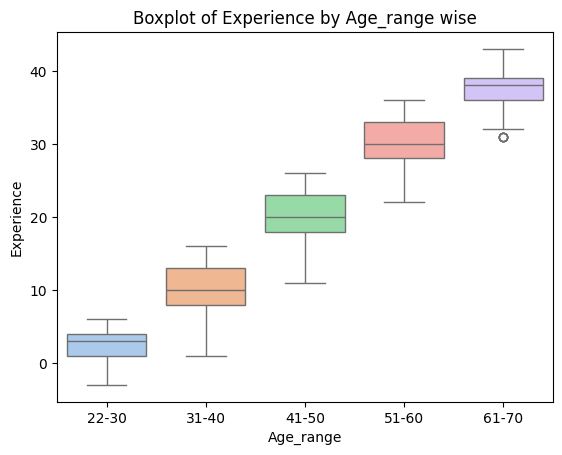

In [27]:
sns.boxplot( x = 'Age_range', y = 'Experience', data = data1, palette = 'pastel')
plt.title('Boxplot of Experience by Age_range wise')
plt.show()

##### THIS INDICATES THAT EXPERIENCE IS HIGHER WHEN THERE ARE HIGH AGE RANGE

#### Step 5 - Preprocessing

In [20]:
data = pd.read_csv("Dataset/bankloan.csv")

In [56]:
data1.dtypes           # as our data1 has categorial values so we cant use this for fitting in model
                       # and also we created this category columns for purpose of visualization.

Age                      int64
Experience               int64
Income                   int64
Family                   int64
CCAvg                  float64
Education                int64
Mortgage                 int64
Personal.Loan            int64
Securities.Account       int64
CD.Account               int64
Online                   int64
CreditCard               int64
Age_range             category
Income_Class          category
dtype: object

In [21]:
data = data.drop(['ID', 'ZIP.Code'], axis = 1)
data.head(5)

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,0,1


In [23]:
X = data.drop('Personal.Loan', axis =1)
y = data['Personal.Loan']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X)

X = pd.DataFrame(X_scaled_array, columns = X.columns)

#### Step 6 - Splitting data and Fitting data into Logistic Regression Model

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X,y, test_size = 0.2, random_state = 42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4000, 11), (1000, 11), (4000,), (1000,))

In [24]:
print(data['Personal.Loan'].head(10))
print(data['Personal.Loan'].unique()[:20])
print(data['Personal.Loan'].dtype)

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    1
Name: Personal.Loan, dtype: int64
[0 1]
int64


In [34]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000, random_state = 42)
logreg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [35]:
y_predicted = logreg.predict(X_test)
output = pd.DataFrame({
    'Predictions' : y_predicted,
    'Actual Values' : y_test
})
output

,Predictions,Actual Values
1501,0,0
2586,0,1
2653,0,0
1055,0,0
705,0,0
...,...,...
4711,0,0
2313,0,0
3214,0,0
2732,0,0


#### Step 7 - Checking Accuracy of Model by Accuracy score & Confusion Matrix. And giving Conclusion based on that.



Logistic Regression model accuracy score is 0.954


A confusion matrix is used to evaluate and understand how well a classification model is performing by comparing its predicted labels with the true labels.


Confusion Matrix :-
[[883  12]
 [ 34  71]]




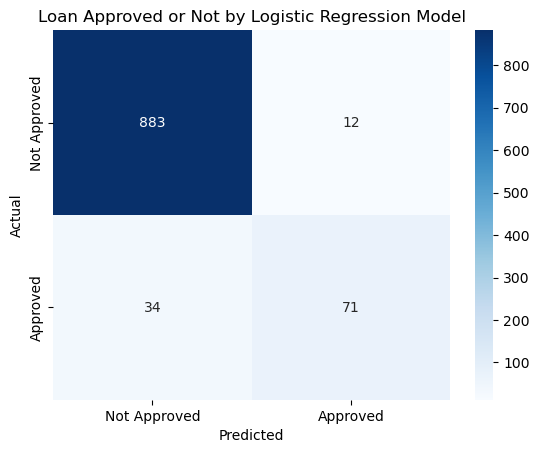

In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("\n")
print('Logistic Regression model accuracy score is {:.3f}'.format(accuracy_score(y_test,y_predicted)))
print("\n")

print("A confusion matrix is used to evaluate and understand how well a classification model is performing by comparing its predicted labels with the true labels.")
print("\n")

cm = confusion_matrix(y_test, y_predicted)

cm = confusion_matrix(y_test, y_predicted)
print('Confusion Matrix :-')
print(cm)  # to see exact counts
print("\n")

sns.heatmap(cm,
            annot = True,
            fmt='d',              # force integer format
            cmap = 'Blues',       # higher contrast
            xticklabels = ['Not Approved','Approved'],
            yticklabels = ['Not Approved','Approved']
           )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Loan Approved or Not by Logistic Regression Model')
plt.savefig('Result of Logistic Regression Algorithm.png', dpi=300, bbox_inches='tight')
plt.show()

**Logistic Regression Results:**

The Logistic Regression model achieved an accuracy of **95%**. This is a solid 
baseline performance for a binary classification task. Logistic Regression is 
particularly valuable because it provides interpretable coefficients — we can 
understand how each feature influences the loan approval decision. However, 
it assumes a linear relationship between features and the target, which may 
limit its ability to capture complex patterns.

#### Step 8 - Going Further for Decision Tree Model

In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

dt_model = DecisionTreeClassifier(random_state = 42)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


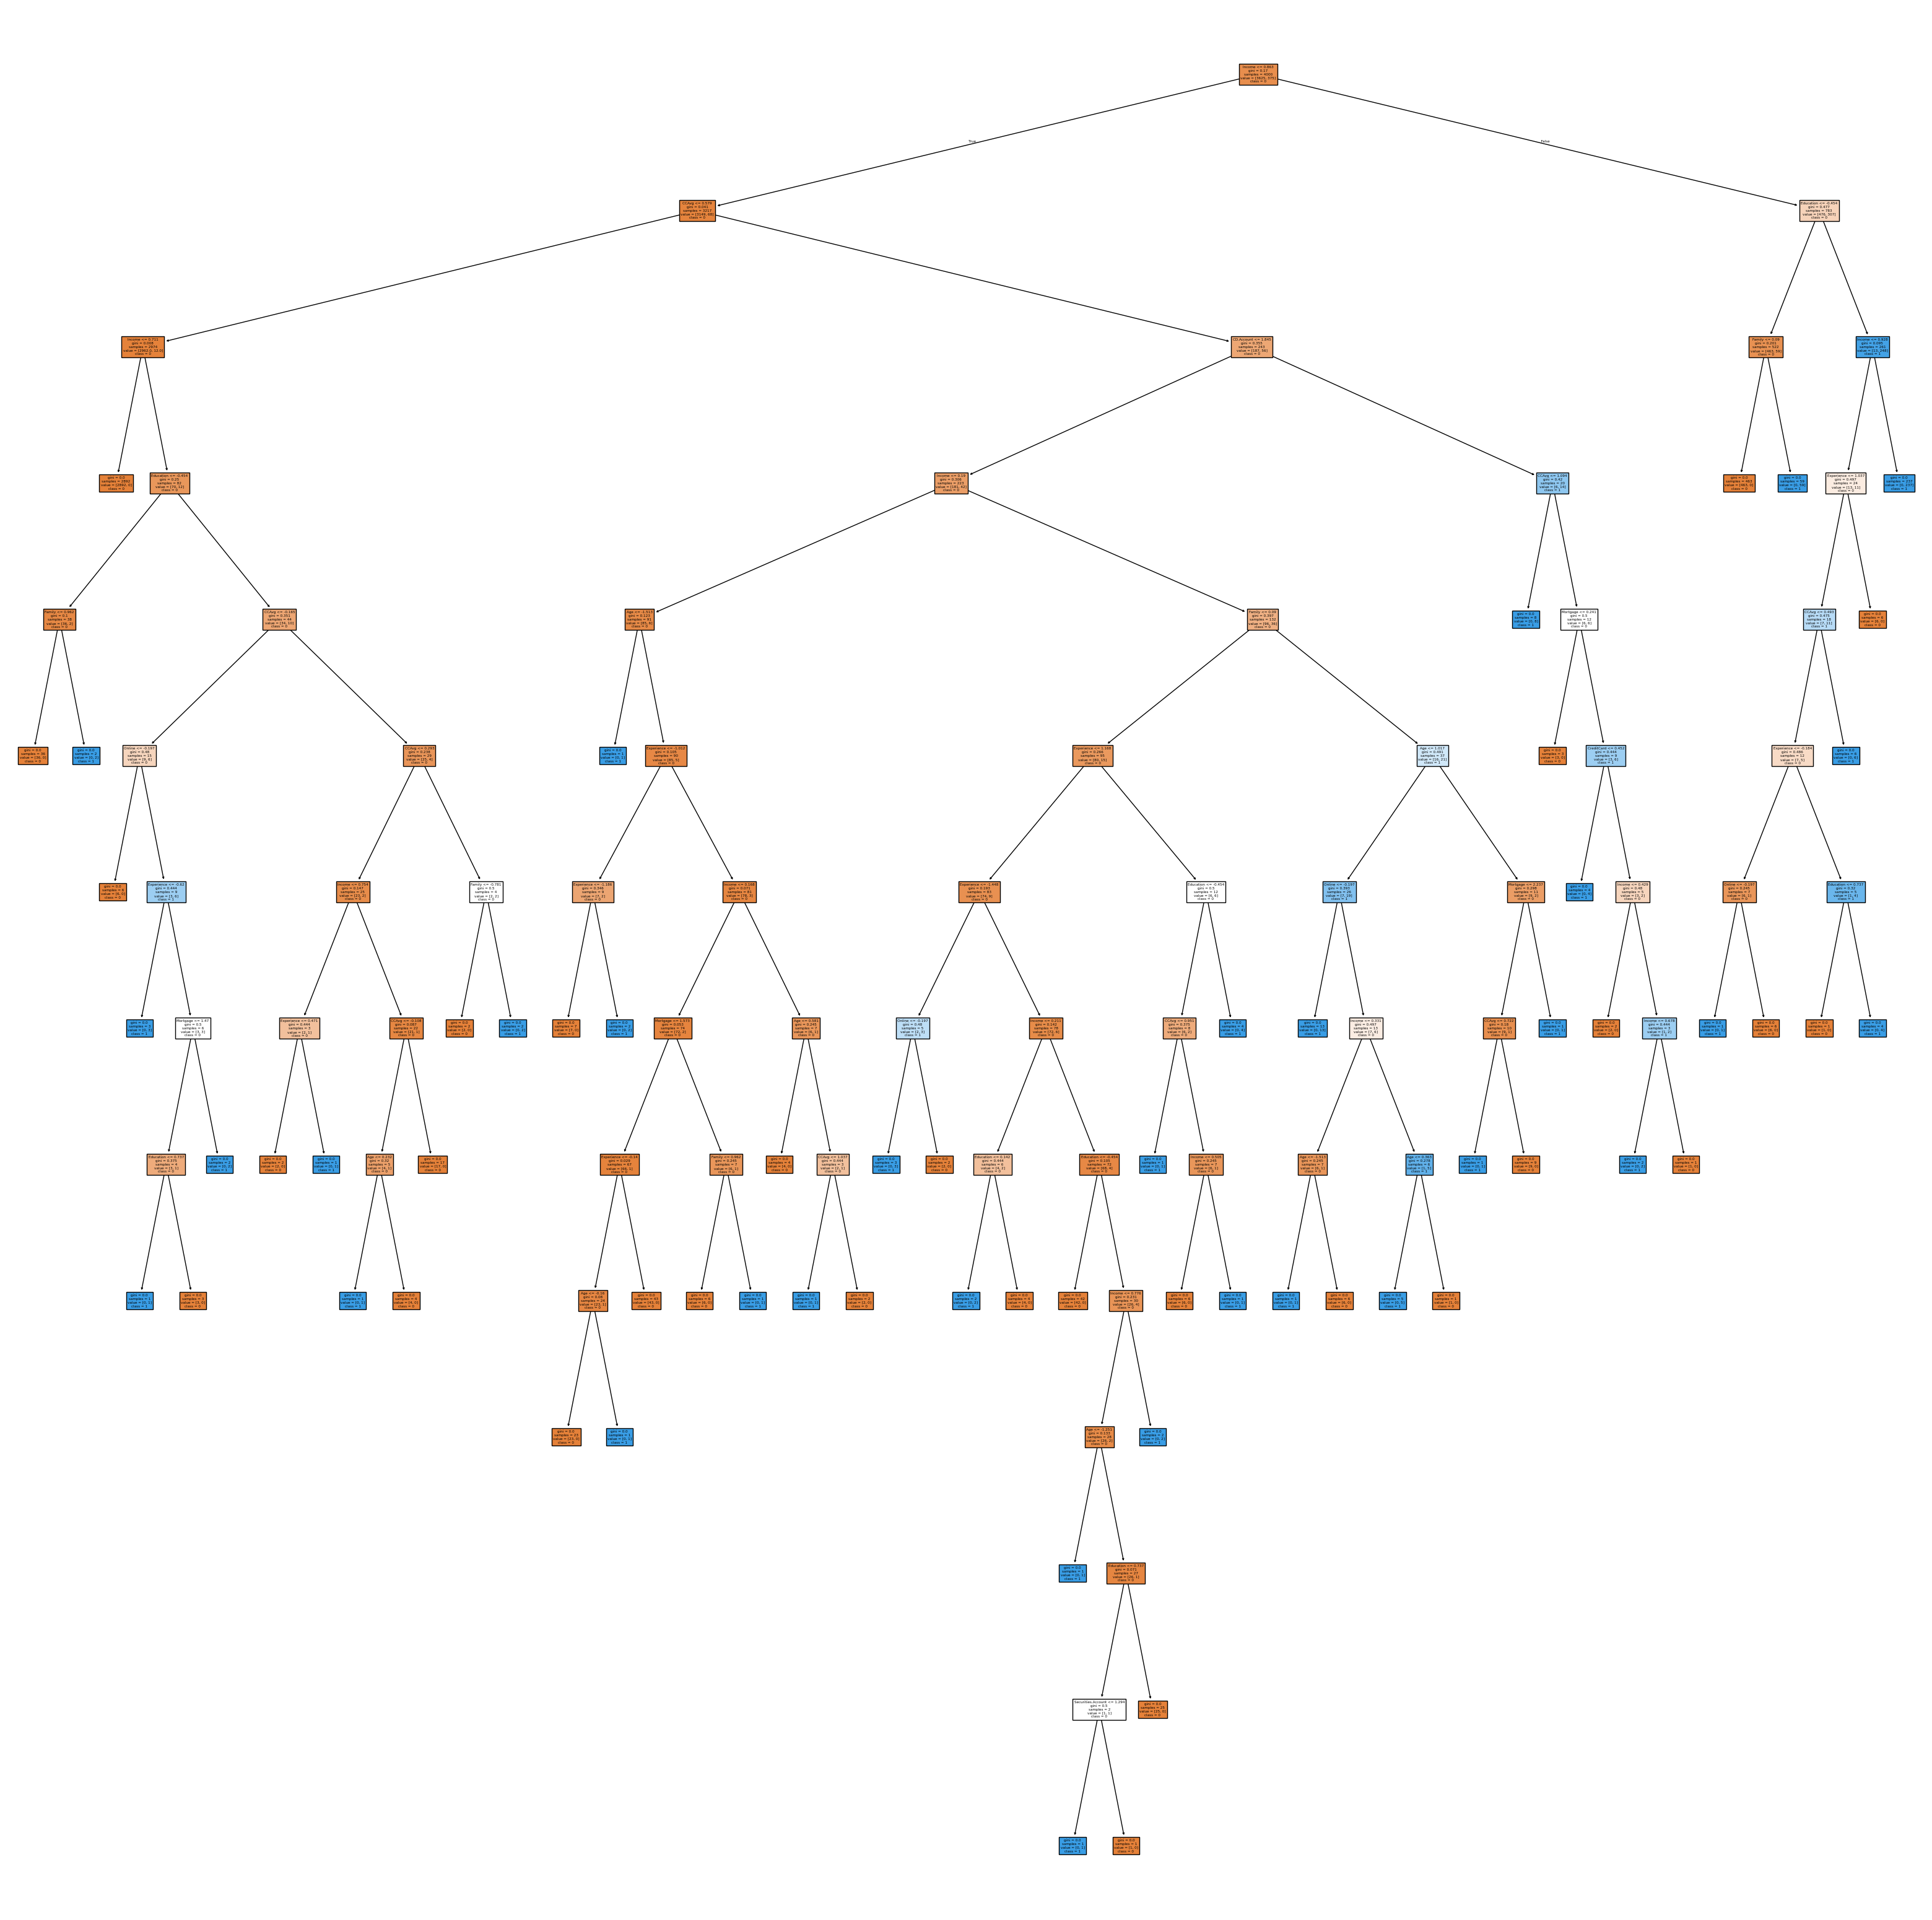

In [38]:
plt.figure(figsize = (40,40))
tree.plot_tree(dt_model,
               filled = True,
               class_names = [str(i) for i in set(y)],
               feature_names = X.columns
              )
plt.savefig('dt_model1',dpi=300, bbox_inches='tight')

In [39]:
y_predicted_of_dt = dt_model.predict(X_test)
y_predicted_of_dt

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [40]:
dt_model.score(X_train, y_train)

1.0

In [41]:
dt_model.score(X_test,y_test)

0.988



 Decision Tree Model Accuracy score is 0.988


Confusion Matrix :-
[[890   5]
 [  7  98]]




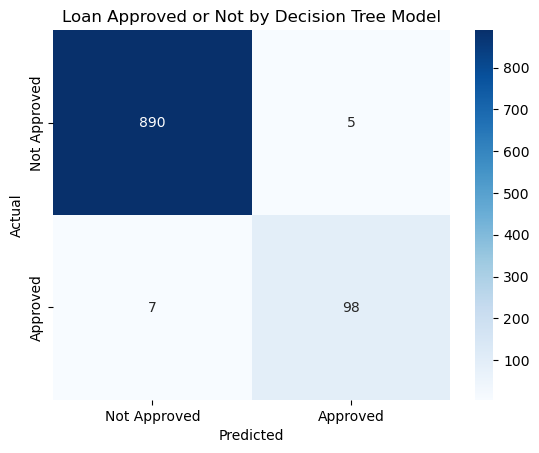

In [42]:
print("\n")
print(' Decision Tree Model Accuracy score is {:.3f}'.format(accuracy_score(y_test, y_predicted_of_dt)))
print("\n")

cm_dt= confusion_matrix(y_test, y_predicted_of_dt)
print('Confusion Matrix :-')
print(cm_dt)  # to see exact counts
print("\n")

sns.heatmap(cm_dt,
            annot = True,
            fmt='d',              # force integer format
            cmap = 'Blues',       # higher contrast
            xticklabels = ['Not Approved','Approved'],
            yticklabels = ['Not Approved','Approved']
           )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Loan Approved or Not by Decision Tree Model')
plt.savefig('Result of Decision Tree Algorithm.png', dpi=300, bbox_inches='tight')
plt.show()

**Decision Tree Results:**

The Decision Tree model achieved an accuracy of **98.8%**, outperforming 
Logistic Regression by 3 percentage points. Decision Trees can capture 
non-linear relationships and do not require feature scaling. They also 
provide visual interpretability through tree visualization. However, 
a single Decision Tree is prone to overfitting, meaning it may not 
generalize well to completely new data.

#### Step 9 - Going Further for Random Forest Model

In [43]:
from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(random_state = 42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
rf_model.score(X_train, y_train)

1.0

In [45]:
rf_model.score(X_test, y_test)

0.991

In [46]:
y_predicted_of_rf = rf_model.predict(X_test)          # creating prediction by rf_model
# y_predicted_of_rf



Random Forest Model given accuracy is 0.991


Confusion Matrix of Random Forest :-
[[894   1]
 [  8  97]]




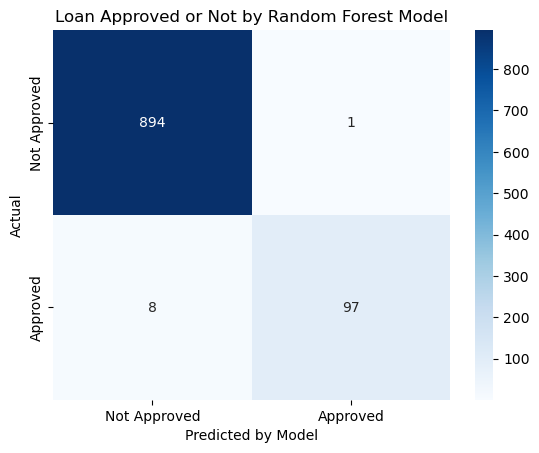

In [47]:
print('\n')
print('Random Forest Model given accuracy is {:.3f}'.format(accuracy_score(y_test, y_predicted_of_rf)))
print('\n')

cm_rf = confusion_matrix(y_test, y_predicted_of_rf)
print('Confusion Matrix of Random Forest :-')
print(cm_rf)
print('\n')

sns.heatmap(cm_rf, 
             annot = True,
             fmt = 'd',           # force integer format
             cmap = 'Blues',      # higher contrast
             xticklabels = ['Not Approved', 'Approved'],
             yticklabels = ['Not Approved', 'Approved']
            )
plt.xlabel('Predicted by Model')
plt.ylabel('Actual')
plt.title('Loan Approved or Not by Random Forest Model')
plt.savefig('Result of Random Forest Algorithm.png', dpi=300, bbox_inches='tight')
plt.show()

**Random Forest Results:**

The Random Forest model achieved the highest accuracy of **99.1%**, 
outperforming both Logistic Regression (95%) and Decision Tree (98%). 
Random Forest is an ensemble method that combines multiple Decision Trees, 
which reduces overfitting and provides more stable predictions. The 
slightly higher accuracy makes it the best choice for this dataset.

#### Step 10 - Going Further for AUC Score(AREA UNDER CURVE) of Model's 

LOGISTIC REGRESSION MODEL AUC : 0.9683213620643789


DECISION TREE MODEL AUC : 0.9638733705772812


RANDOM FOREST MODEL AUC : 0.9991221069433359




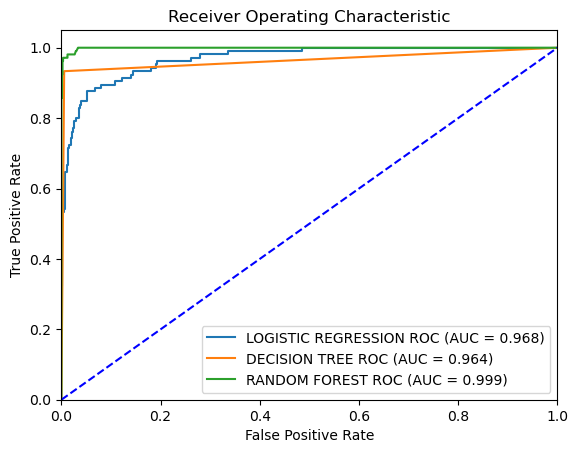

In [48]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

# LOGISTIC REGRESSION MODEL
y_proba_lr = logreg.predict_proba(X_test)[:,1]

auc_lr = roc_auc_score(y_test, y_proba_lr)
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)
print('LOGISTIC REGRESSION MODEL AUC :',auc_lr)
print('\n')


# DECISION TREE MODEL
auc_dt = roc_auc_score(y_test, dt_model.predict_proba(X_test)[:,1])
dt_fpr, dt_tpr, dt_thresholds = roc_curve(y_test, dt_model.predict_proba(X_test)[:,1])
print('DECISION TREE MODEL AUC :',auc_dt)
print('\n')


# RANDOM FOREST MODEL
auc_rf = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1])
rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])
print('RANDOM FOREST MODEL AUC :', auc_rf)
print('\n')


plt.plot(fpr, tpr, label = f"LOGISTIC REGRESSION ROC (AUC = {auc_lr:.3f})")
plt.plot(dt_fpr, dt_tpr, label = f'DECISION TREE ROC (AUC = {auc_dt:.3f})')
plt.plot(rf_fpr, rf_tpr, label = f'RANDOM FOREST ROC (AUC = {auc_rf:.3f})')


plt.plot([0,1], [0,1], 'b--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0,1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')

plt.legend(loc = 'lower right')
plt.savefig('AUC_ROC_CURVE.png', dpi=300, bbox_inches='tight')
plt.show()

---

## Model Comparison Summary

After evaluating all three models using both Accuracy and AUC-ROC, here is the comparison:

| Model | Accuracy | AUC Score |
|-------|----------|-----------|
| Logistic Regression | 95% | [0.968] |
| Decision Tree | 98.8% | [0.964] |
| Random Forest | 99.1% | [0.999] |

---

## Final Recommendation

**Random Forest is the best model** for bank loan approval prediction based on this dataset, achieving 99% accuracy.

**Why Random Forest is preferred:**
- It is an ensemble method that combines multiple Decision Trees
- Reduces overfitting compared to a single Decision Tree
- Provides more stable and reliable predictions
- Achieved the highest accuracy (99%) and best AUC score

**Why Accuracy alone is not enough:**
Our dataset is imbalanced (4520 "Not Approved" vs 480 "Approved"). 
In such cases, AUC-ROC is a more reliable metric because it considers 
both True Positive Rate and False Positive Rate across all thresholds.
The AUC comparison confirms that Random Forest has the best overall 
discriminative ability.

**For production use, Random Forest is recommended.**

## NOW ITS END HERE